In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils.data import DataManager
from utils.analysis.risk_metrics.analyzers import (
    VarEsAnalyzer,
    RatioAnalyzer,
    DistributionAnalyzer,
    BenchmarkAnalyzer,
    DrawdownAnalyzer,
    CorrelationAnalyzer
)

from utils.visualizations import (
    DrawdownVisualizer, 
    DistributionVisualizer, 
    VarEsVisualizer, 
    RatioVisualizer, 
    BenchmarkVisualizer
)

from utils.tools import (
    BENCHMARKS,
    RISK_ANALYSIS,
    INTERPRETATION_THRESHOLDS
)

In [29]:
TICKERS = ["META", "IONQ", "GOOGL", "NVDA", "MSFT", "SMR"] 
BENCHMARK_NAME = "SP500" 
START_DATE = "2020-01-01" 
END_DATE = "2024-12-31"

In [30]:
BENCHMARK_TICKER = BENCHMARKS[BENCHMARK_NAME] 
RISK_FREE_RATE = RISK_ANALYSIS['risk_free_rate']
ANNUAL_FACTOR = RISK_ANALYSIS['annual_factor']
DEFAULT_CONFIDENCE = RISK_ANALYSIS['default_confidence_level']
CONFIDENCE_LEVELS = RISK_ANALYSIS['default_confidence_levels']
ROLLING_WINDOW = RISK_ANALYSIS['rolling']['default_window']
MC_SIMULATIONS = RISK_ANALYSIS['monte_carlo']['n_simulations']
MC_SEED = RISK_ANALYSIS['monte_carlo']['seed']
WEIGHTS = np.ones(len(TICKERS)) / len(TICKERS)
SKEW_THRESH = INTERPRETATION_THRESHOLDS['skewness']
KURT_THRESH = INTERPRETATION_THRESHOLDS['kurtosis']

In [31]:
data_manager = DataManager()
var_es_analyzer = VarEsAnalyzer(annual_factor=ANNUAL_FACTOR)
ratio_analyzer = RatioAnalyzer(annual_factor=ANNUAL_FACTOR)
dist_analyzer = DistributionAnalyzer()
benchmark_analyzer = BenchmarkAnalyzer(annual_factor=ANNUAL_FACTOR)
drawdown_analyzer = DrawdownAnalyzer(annual_factor=ANNUAL_FACTOR)
correlation_analyzer = CorrelationAnalyzer()
ratio_visualizer = RatioVisualizer(annual_factor=ANNUAL_FACTOR)
benchmark_visualizer = BenchmarkVisualizer(annual_factor=ANNUAL_FACTOR)
distribution_visualizer = DistributionVisualizer()
drawdown_visualizer = DrawdownVisualizer()
var_es_visualizer = VarEsVisualizer(annual_factor=ANNUAL_FACTOR)

## Data Loader

In [32]:
assets_prices, benchmark_prices = data_manager.download_portfolio_with_benchmark(
    tickers=TICKERS,
    benchmark_name=BENCHMARK_NAME,
    start_date=START_DATE,
    end_date=END_DATE
)

returns = assets_prices.pct_change().dropna()
benchmark_returns = benchmark_prices.pct_change().dropna()

[                       0%                       ]

Descargando portafolio completo...
Período: 2020-01-01 → 2024-12-31


[*********************100%***********************]  6 of 6 completed
[*********************100%***********************]  1 of 1 completed

Período: 2020-01-01 → 2024-12-31
Portafolio descargado: 6 activos + benchmark


## Main

In [33]:
all_ratios = ratio_analyzer.calculate_all_ratios(
    returns, 
    WEIGHTS, 
    RISK_FREE_RATE 
)

df_ratios = pd.DataFrame({
    'Valor Formateado': [
        f"{all_ratios['sharpe_ratio']:.3f}",
        f"{all_ratios['sortino_ratio']:.3f}",
        f"{all_ratios['annual_return']*100:.2f}%",
        f"{all_ratios['annual_volatility']*100:.2f}%",
        f"{all_ratios['downside_volatility']*100:.2f}%",
        f"{all_ratios['excess_return']*100:.2f}%",
        f"{all_ratios['risk_free_rate']*100:.2f}%"
    ]
}, index=[
    'Sharpe Ratio',
    'Sortino Ratio',
    'Retorno Anual',
    'Volatilidad Anual',
    'Volatilidad Downside',
    'Exceso de Retorno',
    'Tasa Libre de Riesgo'
])

print("RATIOS DE RIESGO-RETORNO")
display(df_ratios)

RATIOS DE RIESGO-RETORNO


,Valor Formateado
Sharpe Ratio,1.223
Sortino Ratio,2.057
Retorno Anual,51.77%
Volatilidad Anual,38.64%
Volatilidad Downside,22.98%
Exceso de Retorno,47.27%
Tasa Libre de Riesgo,4.50%


In [34]:
dist_results = dist_analyzer.analyze(returns, WEIGHTS)

print("ESTADÍSTICAS BÁSICAS")
print(f"  Media:              {dist_results['mean']:>10.4f} ({dist_results['mean']*100:>7.2f}%)")
print(f"  Mediana:            {dist_results['median']:>10.4f} ({dist_results['median']*100:>7.2f}%)")
print(f"  Desv. Estándar:     {dist_results['std']:>10.4f} ({dist_results['std']*100:>7.2f}%)")
print(f"  Skewness:           {dist_results['skewness']:>10.3f}")
print(f"  Excess Kurtosis:    {dist_results['excess_kurtosis']:>10.3f}")

# Interpretación usando umbrales de config
skew = dist_results['skewness']
if skew > SKEW_THRESH['positive']:
    skew_interp = "Asimetría positiva (cola derecha)"
elif skew < SKEW_THRESH['negative']:
    skew_interp = "Asimetría negativa (cola izquierda)"
else:
    skew_interp = "Aproximadamente simétrica"
print(f"  Interpretación:     {skew_interp}")

# Interpretación kurtosis usando config
kurt = dist_results['excess_kurtosis']
if kurt > KURT_THRESH['positive']:
    kurt_interp = "Leptocúrtica (colas pesadas)"
elif kurt < KURT_THRESH['positive']:
    kurt_interp = "Platicúrtica (colas ligeras)"
else:
    kurt_interp = "Mesocúrtica (normal)"
print(f"  Interpretación:     {kurt_interp}")

ESTADÍSTICAS BÁSICAS
  Media:                  0.0021 (   0.21%)
  Mediana:                0.0018 (   0.18%)
  Desv. Estándar:         0.0243 (   2.43%)
  Skewness:                0.146
  Excess Kurtosis:         0.707
  Interpretación:     Aproximadamente simétrica
  Interpretación:     Leptocúrtica (colas pesadas)


In [35]:
print("TEST DE NORMALIDAD (Jarque-Bera)")
print(f"  Estadístico JB:     {dist_results['jb_statistic']:>10.3f}")
print(f"  p-value:            {dist_results['jb_p_value']:>10.4f}")
normal_icon = "Sí" if dist_results['is_normal'] else "No"
print(f"  ¿Distribución Normal?  {normal_icon}")

TEST DE NORMALIDAD (Jarque-Bera)
  Estadístico JB:         16.775
  p-value:                0.0002
  ¿Distribución Normal?  No


In [36]:
print("PERCENTILES")
print(f"  1%:                 {dist_results['percentile_1']*100:>10.2f}%")
print(f"  5%:                 {dist_results['percentile_5']*100:>10.2f}%")
print(f"  95%:                {dist_results['percentile_95']*100:>10.2f}%")
print(f"  99%:                {dist_results['percentile_99']*100:>10.2f}%")

PERCENTILES
  1%:                      -5.87%
  5%:                      -3.79%
  95%:                      4.14%
  99%:                      6.18%


In [37]:
multi_results = var_es_analyzer.calculate_multi_level(
    returns, 
    WEIGHTS, 
    confidence_levels=(0.95, 0.99)
)

for conf_level, methods_dict in multi_results.items():
    print(f"NIVEL DE CONFIANZA: {conf_level*100:.0f}%")
    rows = []
    for method, metrics in methods_dict.items():
        rows.append({
            'Método': method.capitalize(),
            'VaR Diario': f"{metrics['var_daily_pct']:>7.2f}%",
            'ES Diario': f"{metrics['es_daily_pct']:>7.2f}%",
            'VaR Anual': f"{metrics['var_annual_pct']:>7.2f}%",
            'ES Anual': f"{metrics['es_annual_pct']:>7.2f}%"
        })
    
    df = pd.DataFrame(rows)
    display(df)

NIVEL DE CONFIANZA: 95%


,Método,VaR Diario,ES Diario,VaR Anual,ES Anual
0,Historical,-3.79%,-4.83%,-60.20%,-76.66%
1,Parametric,-3.80%,-4.82%,-60.30%,-76.44%
2,Monte_carlo,-3.87%,-4.89%,-61.43%,-77.59%


NIVEL DE CONFIANZA: 99%


,Método,VaR Diario,ES Diario,VaR Anual,ES Anual
0,Historical,-5.87%,-6.34%,-93.22%,-100.57%
1,Parametric,-5.46%,-6.28%,-86.63%,-99.73%
2,Monte_carlo,-5.57%,-6.43%,-88.47%,-102.04%


In [38]:
bench_results = benchmark_analyzer.analyze(
    returns, 
    WEIGHTS, 
    benchmark_returns, 
    RISK_FREE_RATE
)

print("ANÁLISIS VS BENCHMARK")
print(f"Tracking Error:")
print(f"  Diario:         {bench_results['tracking_error_daily']*100:>8.2f}%")
print(f"  Anual:          {bench_results['tracking_error_annual']*100:>8.2f}%")

print(f"Information Ratio:")
print(f"  IR:             {bench_results['information_ratio']:>8.3f}")
print(f"  Exceso Retorno: {bench_results['excess_return_annual']*100:>8.2f}%")

print(f"Beta y Correlación:")
print(f"  Beta:           {bench_results['beta']:>8.3f}")
print(f"  R²:             {bench_results['r_squared']:>8.3f}")
print(f"  Correlación:    {bench_results['correlation']:>8.3f}")

print(f"Alpha (Jensen):")
print(f"  Alpha Anual:    {bench_results['alpha_annual']*100:>8.2f}%")
print(f"  Retorno Portfolio: {bench_results['portfolio_return_annual']*100:>7.2f}%")
print(f"  Retorno Benchmark: {bench_results['benchmark_return_annual']*100:>7.2f}%")
print(f"  Retorno Esperado:  {bench_results['expected_return']*100:>7.2f}%")

ANÁLISIS VS BENCHMARK
Tracking Error:
  Diario:             1.74%
  Anual:             27.61%
Information Ratio:
  IR:                1.416
  Exceso Retorno:    39.08%
Beta y Correlación:
  Beta:              1.724
  R²:                0.595
  Correlación:       0.771
Alpha (Jensen):
  Alpha Anual:       33.16%
  Retorno Portfolio:   51.77%
  Retorno Benchmark:   12.69%
  Retorno Esperado:    18.61%


In [39]:
dd_results = drawdown_analyzer.analyze(returns, WEIGHTS, RISK_FREE_RATE)

print("ANÁLISIS DE DRAWDOWN")
print(f"Max Drawdown:")
print(f"  Magnitud:       {dd_results['max_drawdown_pct']:>8.2f}%")
print(f"  Fecha:          {dd_results['max_drawdown_date'].date()}")
print(f"  Duración:       {dd_results['max_underwater_duration']} días")

print(f"Ratios de Drawdown:")
print(f"  Calmar Ratio:   {dd_results['calmar_ratio']:>8.3f}")
print(f"  Sterling Ratio: {dd_results['sterling_ratio']:>8.3f}")

print(f"Retorno Anual:    {dd_results['annual_return']*100:>8.2f}%")

ANÁLISIS DE DRAWDOWN
Max Drawdown:
  Magnitud:         -41.84%
  Fecha:          2022-12-28
  Duración:       283 días
Ratios de Drawdown:
  Calmar Ratio:      1.237
  Sterling Ratio:    1.165
Retorno Anual:       51.77%


In [40]:
if len(TICKERS) > 1:
    corr_results = correlation_analyzer.analyze(returns)
    
    print("ANÁLISIS DE CORRELACIÓN")
    print(f"Estadísticas:")
    print(f"  Correlación Media: {corr_results['mean_correlation']:>8.3f}")
    print(f"  Correlación Min:   {corr_results['min_correlation']:>8.3f}")
    print(f"  Correlación Max:   {corr_results['max_correlation']:>8.3f}")
    print(f"  Desv. Estándar:    {corr_results['std_correlation']:>8.3f}")
    
    print("\nMatriz de Correlación:")
    display(corr_results['correlation_matrix'])

ANÁLISIS DE CORRELACIÓN
Estadísticas:
  Correlación Media:    0.370
  Correlación Min:      0.047
  Correlación Max:      0.685
  Desv. Estándar:       0.210

Matriz de Correlación:


,META,IONQ,GOOGL,NVDA,MSFT,SMR
META,1.000000,0.334706,0.606669,0.500233,0.595434,0.046540
IONQ,0.334706,1.000000,0.354335,0.363306,0.362729,0.241591
GOOGL,0.606669,0.354335,1.000000,0.535149,0.685307,0.103283
NVDA,0.500233,0.363306,0.535149,1.000000,0.625314,0.117562
MSFT,0.595434,0.362729,0.685307,0.625314,1.000000,0.077590
SMR,0.046540,0.241591,0.103283,0.117562,0.077590,1.000000


In [41]:
# Ratios rolling
rolling_ratios = ratio_analyzer.calculate_rolling(
    returns, WEIGHTS, RISK_FREE_RATE, window=ROLLING_WINDOW
)
# Benchmark rolling
rolling_bench = benchmark_analyzer.analyze_rolling(
    returns, WEIGHTS, benchmark_returns, window=ROLLING_WINDOW
)

## Visualizations

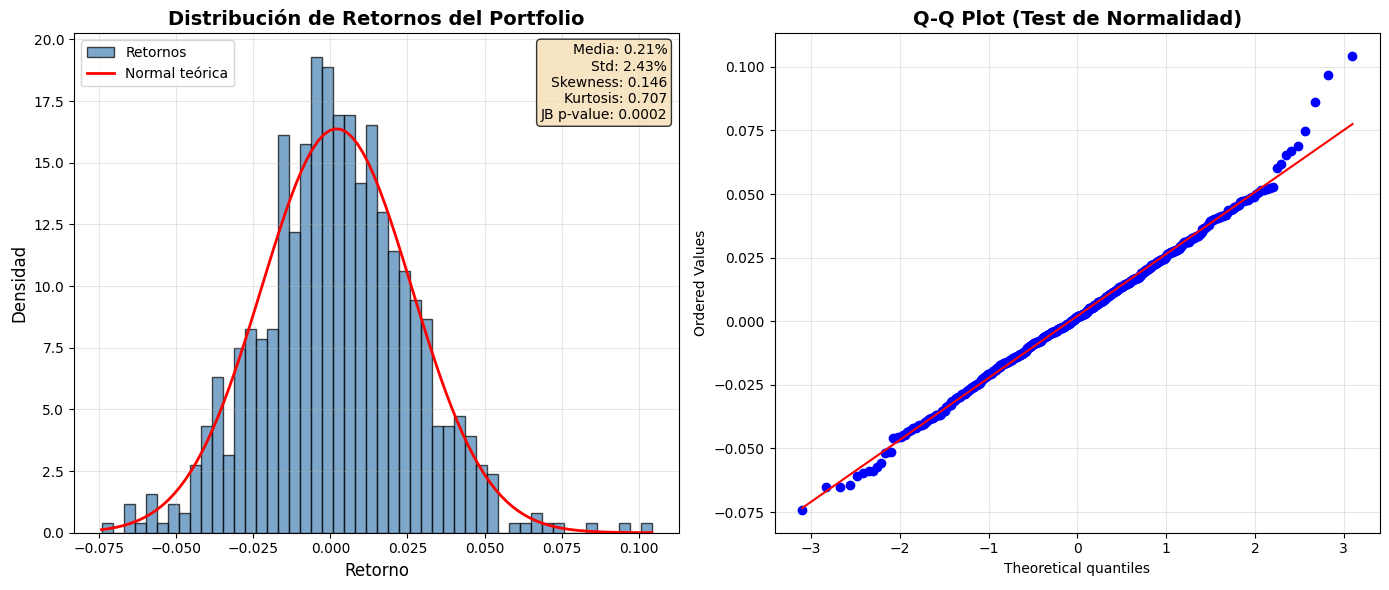

In [42]:
dist_viz = DistributionVisualizer()
dist_viz.plot_distribution_analysis(
    returns=returns,
    weights=WEIGHTS,
    dist_results=dist_results,  
    figsize=(14, 6)
)
plt.show()

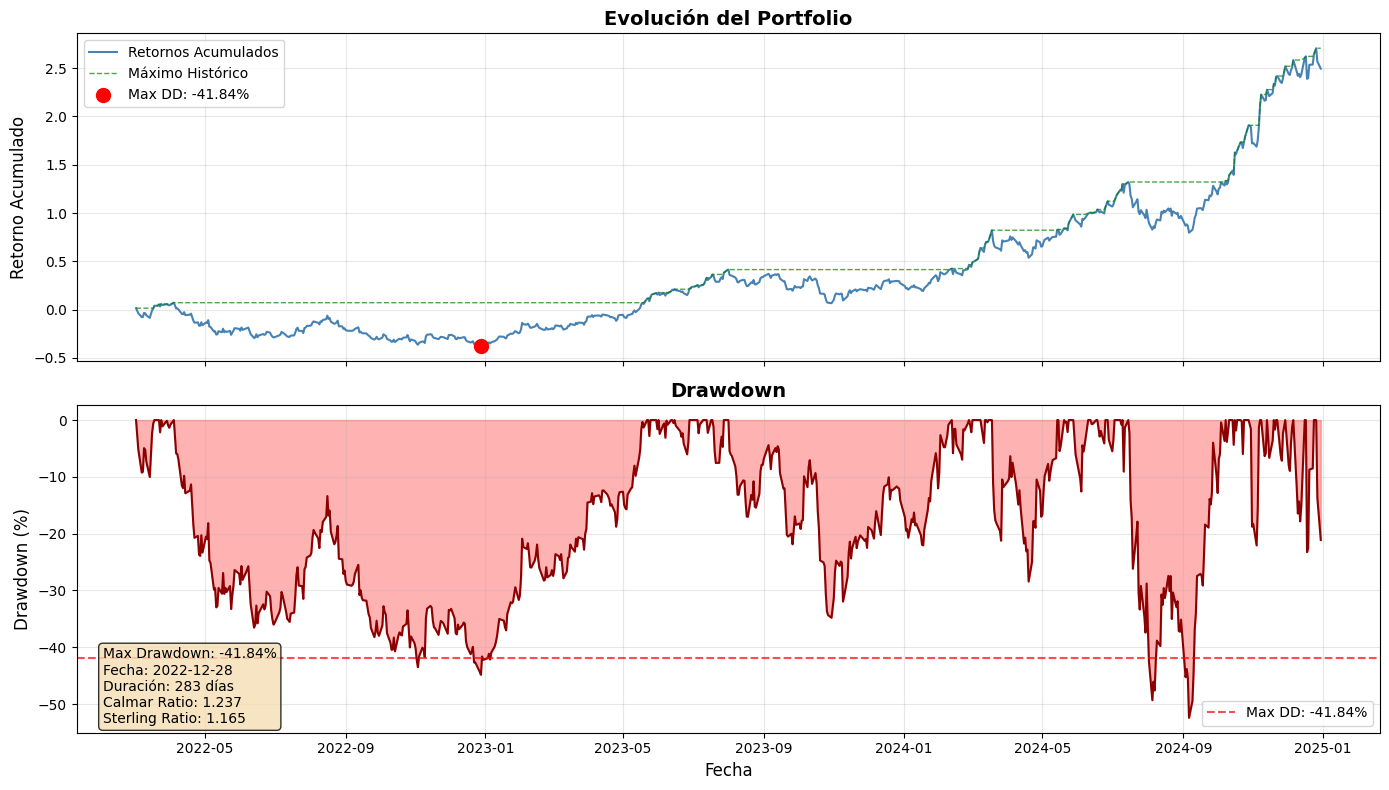

In [43]:
dd_viz = DrawdownVisualizer(annual_factor=ANNUAL_FACTOR)
dd_viz.plot_drawdown_analysis(
    returns=returns,
    weights=WEIGHTS,
    dd_results=dd_results,
    figsize=(14, 8)
)
plt.show()

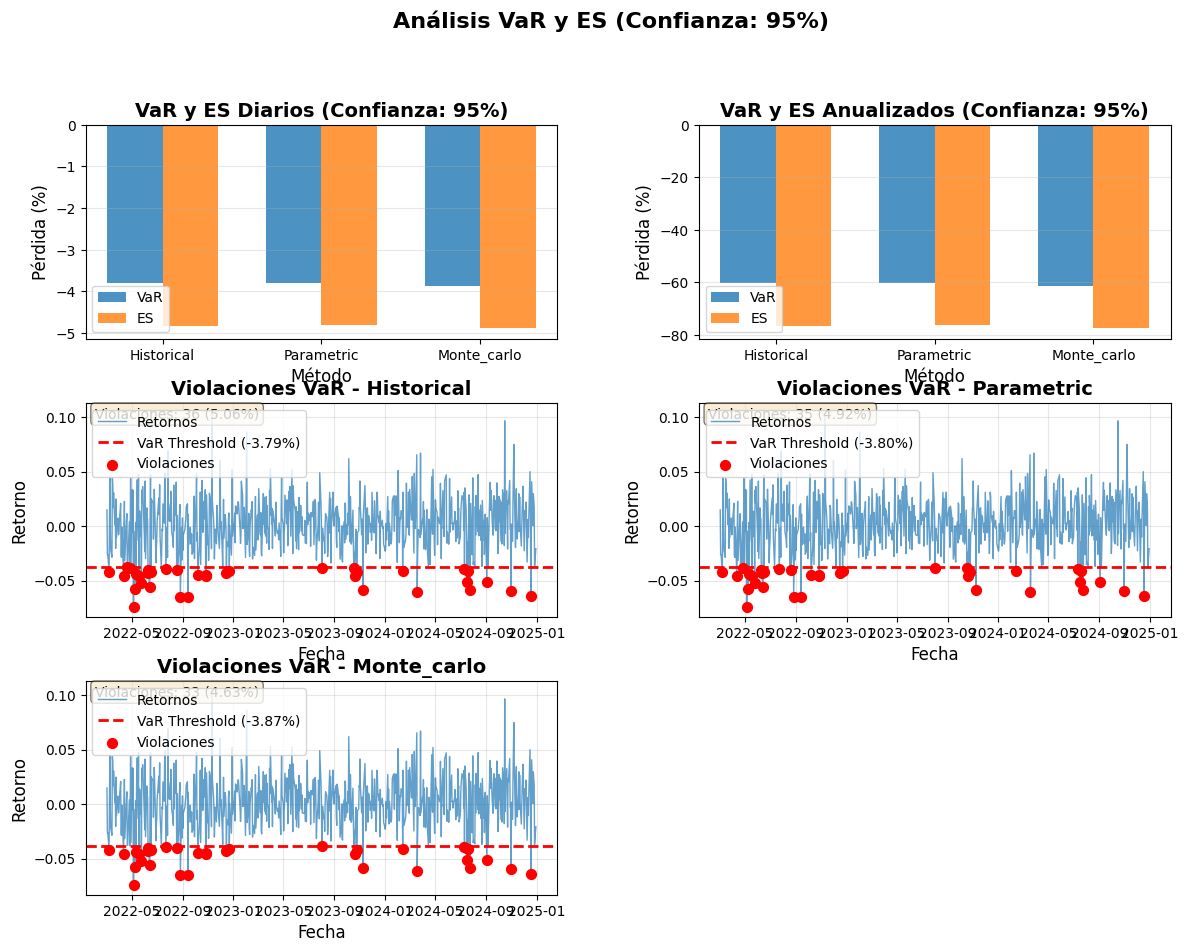

In [44]:
var_viz = VarEsVisualizer(annual_factor=ANNUAL_FACTOR)
var_viz.plot_var_es_analysis(
    returns=returns,
    weights=WEIGHTS,
    var_es_results=multi_results,
    confidence_level=DEFAULT_CONFIDENCE,
    figsize=(14, 10)
)
plt.show()

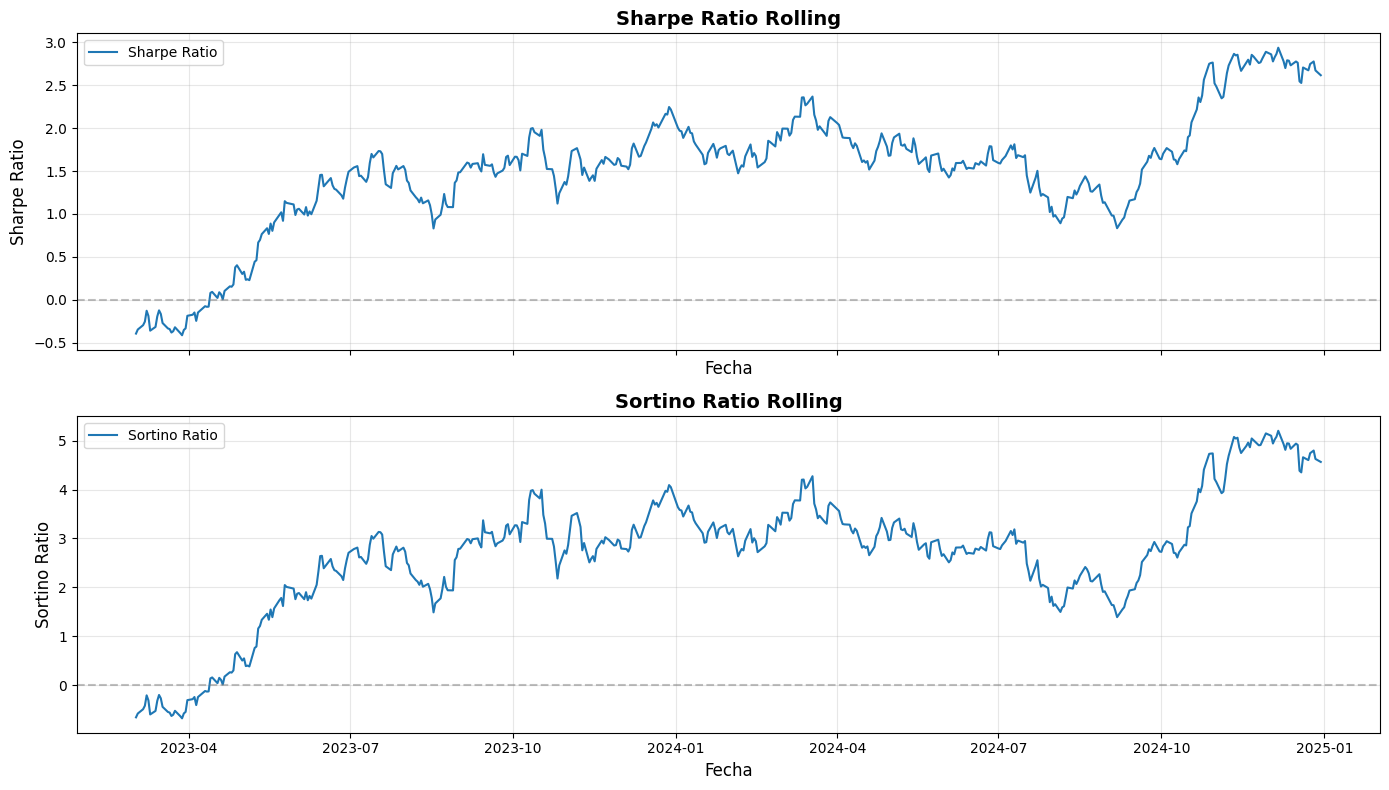

In [45]:
ratio_viz = RatioVisualizer(annual_factor=ANNUAL_FACTOR)
ratio_viz.plot_rolling_ratios(
    rolling_data=rolling_ratios, 
    figsize=(14, 8)
)
plt.show()

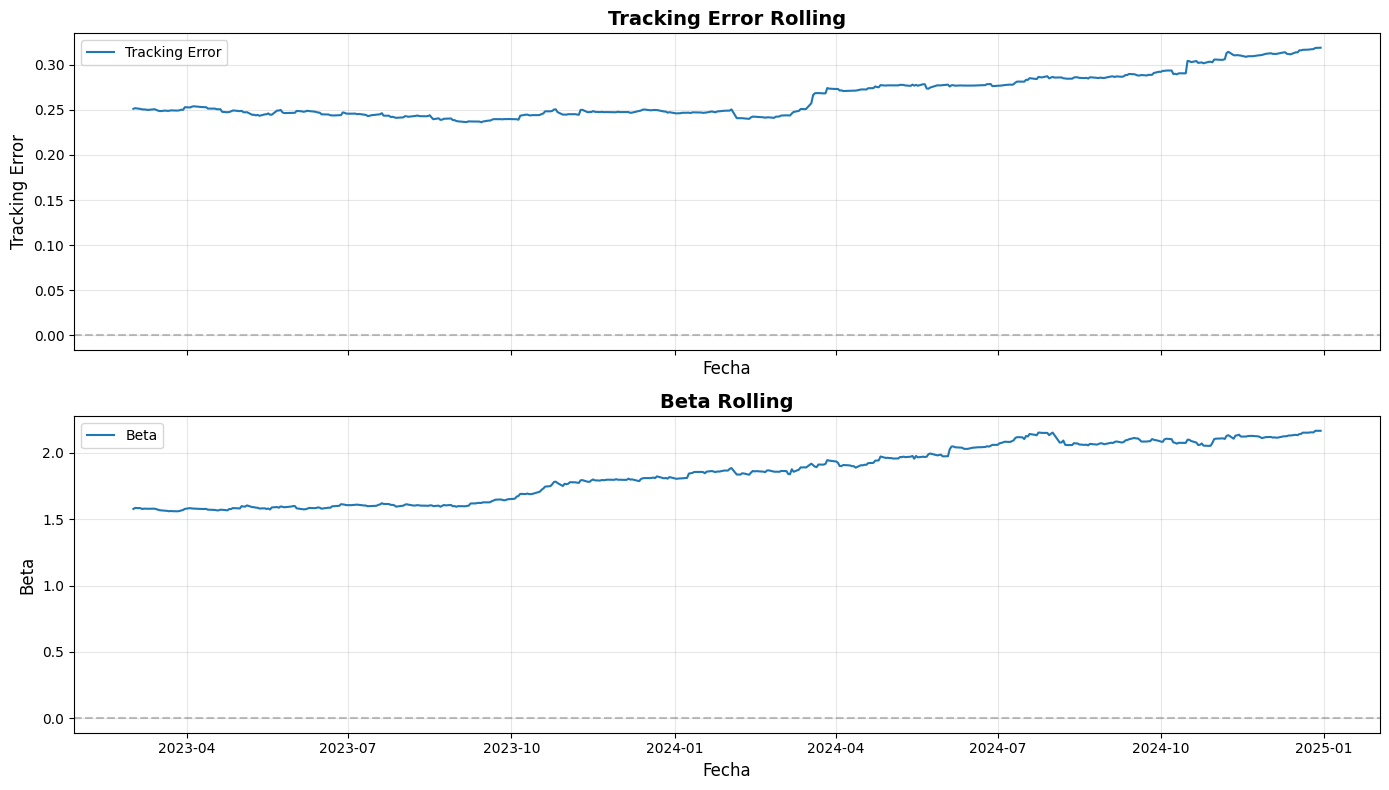

In [46]:
bench_viz = BenchmarkVisualizer(annual_factor=ANNUAL_FACTOR)
bench_viz.plot_rolling_benchmark(
    rolling_data=rolling_bench,
    figsize=(14, 8)
)
plt.show()